# Calibration & Threshold Selection

*How much can we trust the model's probabilities, and where should we draw the line to act on them?*

A model can rank customers correctly — putting likely churners above unlikely ones — while still getting the actual probabilities wrong. **Calibration** is what fixes that: a well-calibrated model's 0.7 means "about 70% of these customers actually churn," not just "these customers rank higher than the 0.3s." That distinction matters here because the threshold this notebook derives only makes sense against honest probabilities.

This notebook walks through two already-computed results: how the calibration method was chosen (Section 2), and how the calibrated probabilities were converted into a single, cost-based threshold for deciding who to contact (Section 3).

In [1]:
%matplotlib inline

from __future__ import annotations

import warnings

warnings.filterwarnings("ignore")

import os

os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

import mlflow
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, display

load_dotenv()

from telco_churn.utils.logging import configure_logging
from telco_churn.utils.mlflow import resolve_tracking_uri
from telco_churn.utils.paths import compose_config

configure_logging()
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

## 1. Load the calibration + threshold run from MLflow

### Connect and locate the run

Calibration and threshold derivation are both logged onto the *same* MLflow run as the `tuning_study` parent — not separate named runs — since `calibrate.py` performs the training cycle's single registration by rebinding that run's model artifact rather than creating a new one. This notebook pulls the **most recent** `tuning_study` run that has a logged `threshold.json` — the last artifact in the chain — which excludes any run where calibration or threshold derivation was interrupted partway through.

In [2]:
cfg = compose_config()

mlflow.set_tracking_uri(resolve_tracking_uri(str(cfg.mlflow.tracking_uri)))

client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(cfg.mlflow.experiment_name)
if exp is None or exp.lifecycle_stage != "active":
    raise RuntimeError(
        f"No active MLflow experiment named '{cfg.mlflow.experiment_name}' found "
        f"(tracking_uri={mlflow.get_tracking_uri()}). Run the training, calibration, "
        "and threshold steps first."
    )

runs = client.search_runs(
    [exp.experiment_id],
    filter_string="attributes.run_name = 'tuning_study'",
    order_by=["start_time DESC"],
    max_results=20,
)
run_id = None
for run in runs:
    artifact_names = {a.path for a in client.list_artifacts(run.info.run_id)}
    if "threshold.json" in artifact_names:
        run_id = run.info.run_id
        break
if run_id is None:
    raise RuntimeError(
        f"No 'tuning_study' run with a logged 'threshold.json' found in experiment "
        f"'{cfg.mlflow.experiment_name}'. Run calibrate.py then threshold.py first."
    )

print(f"run_id: {run_id}")

run_id: e914ce081bc14a1aa14d0f2ed7d876e9


## 2. Calibration — method selection

### Sigmoid vs. isotonic, on outer-OOF development probabilities

Two calibration methods — **sigmoid** and **isotonic** — are compared against the uncalibrated baseline on identical cross-validation folds. Isotonic is disqualified first if it makes the model's customer-ranking ability (PR-AUC) meaningfully worse: a calibration method should sharpen probabilities, not damage risk-ranking. Only a method that clears that check is then judged on calibration quality — **Brier score** and **Expected Calibration Error (ECE)**, both explained below.

In [3]:
calibration_summary = mlflow.artifacts.load_dict(f"runs:/{run_id}/calibration_summary.json")

diagnostics_df = pd.DataFrame(calibration_summary["diagnostics"]).T
diagnostics_df.columns = ["per_fold_mean_ap", "pooled_brier", "ece", "bss"]
display(diagnostics_df.style.format("{:.4f}"))

print(f"\nSelected method: {calibration_summary['method']}")
switch = calibration_summary.get("switch_decision")
if switch:
    print(f"Decision rule: {switch['decision_rule']}")

,per_fold_mean_ap,pooled_brier,ece,bss
dummy_prior,0.2654,0.1949,0.0000,0.0000
uncalibrated,0.6669,0.1611,0.1446,0.1735
sigmoid,0.6669,0.1345,0.0217,0.3098
isotonic,0.6466,0.1339,0.0112,0.3131



Selected method: sigmoid
Decision rule: isotonic_disqualified_pr_auc_gate


**Brier score** measures how close predicted probabilities are to what actually happened (lower is better). **Expected Calibration Error (ECE)** measures the average gap between predicted and observed rates across probability bins (also lower is better). Isotonic wins on both — but it degrades ranking past the pre-set threshold, so it's disqualified before its calibration scores even count. Sigmoid keeps ranking exactly intact while still recovering most of isotonic's calibration gain.

Brier score alone is hard to judge in isolation — 0.13 doesn't mean much without a reference point. **Brier Skill Score (BSS)** fixes this by comparing each method to a naive baseline that always guesses the overall churn rate (`dummy_prior`, BSS = 0 by definition). Sigmoid's BSS of 0.31 means the calibrated model captures 31% of the possible improvement over that naive guess.

### Reliability diagram — uncalibrated vs. sigmoid-calibrated

Customers are grouped by predicted probability, then checked against what actually happened. The **top panel** plots each group's predicted vs. actual churn rate — the closer to the dashed diagonal, the better calibrated. The **bottom panel** shows how many customers are in each group, so a point on the curve backed by hundreds of customers can be told apart from one backed by just a few.

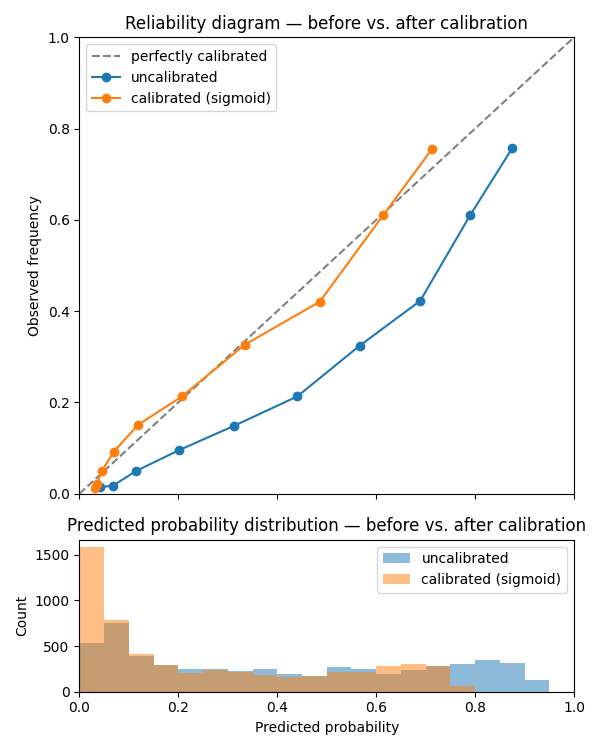

In [4]:
reliability_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="figures/reliability_diagram.png"
)
display(Image(filename=reliability_path))

The uncalibrated model (blue) is consistently overconfident: it predicts more churn than actually happens, at every point on the chart — customers it scored around 87% likely to churn, for example, actually churned only 76% of the time. This comes from a training technique that helps the model notice rarer churn cases, which has the side effect of inflating every prediction. The calibrated model (orange) isn't perfect either, but its small errors go both ways — sometimes a little high, sometimes a little low — instead of always leaning the same direction, which is a much better sign.

The histogram below shows the difference clearly: after calibration, most predictions cluster near 0%, matching the fact that only about 26.5% of customers actually churn. The uncalibrated model spreads its guesses much further toward the high end.

## 3. Cost-sensitive threshold derivation

The calibrated model outputs a churn probability `q` for each customer. The decision rule built on top of it is simple: contact the customer if `q` is at or above some cutoff, and leave them alone otherwise. That cutoff is what the rest of this section calls **`t*`** — the operating threshold — and everything below is about finding the right value for it.

### Business cost parameters, by scenario

Contacting a customer only pays off if the expected benefit outweighs the cost: how much a customer is worth, times how often a retention offer actually works, has to beat what it costs to reach out. Three scenarios below bracket the one number this dataset can't measure directly — how often a retention offer actually works — taken from an industry benchmark instead.

In [5]:
threshold_payload = mlflow.artifacts.load_dict(f"runs:/{run_id}/threshold.json")

cost_rows = []
for name, scenario in threshold_payload["scenarios"].items():
    costs = scenario["costs"]
    cost_rows.append(
        {
            "scenario": name,
            "ARPU ($)": costs["arpu"],
            "1-yr Lifetime Value, LTV ($)": costs["ltv"],
            "Retention rate": costs["r"],
            "Cost per contact ($)": costs["c"],
        }
    )
cost_df = pd.DataFrame(cost_rows).set_index("scenario")
display(
    cost_df.style.format(
        {
            "ARPU ($)": "{:.2f}",
            "1-yr Lifetime Value, LTV ($)": "{:.2f}",
            "Retention rate": "{:.0%}",
            "Cost per contact ($)": "{:.2f}",
        }
    )
)

,ARPU ($),"1-yr Lifetime Value, LTV ($)",Retention rate,Cost per contact ($)
scenario,,,,
conservative,56.67,408.06,20%,22.00
base,79.60,573.12,30%,67.76
optimistic,94.20,678.24,40%,134.78


### Derived thresholds and agreement diagnostics

The threshold comes from a simple rule: only contact a customer if the expected payoff — their value, times how often the offer actually works — is worth more than what it costs to reach out. Solving that rule for the break-even point gives a formula: **threshold = cost ÷ (retention rate × lifetime value)**.

As a sanity check, we can also find the threshold empirically: sweep every possible cutoff, and for each one tally the net value of contacting everyone above it — cost of the contacts against value recovered from the churners among them — to see which cutoff would have performed best on this historical data. That empirical best is noisy, since nearby cutoffs tend to perform almost as well, so rather than expecting it to exactly match `t*`, we resample the data to build a plausible range for where it could fall and check whether `t*` lands inside. The table below reports that check for all three scenarios, not just the one that ships.

,Threshold (formula),Threshold (empirical),95% CI lower,95% CI upper,Within CI?,Contact rate
scenario,,,,,,
conservative,0.2696,0.2672,0.2120,0.3316,Yes,40.3%
base,0.3941,0.4428,0.3645,0.5320,Yes,30.8%
optimistic,0.4968,0.5515,0.4942,0.5932,Yes,24.5%


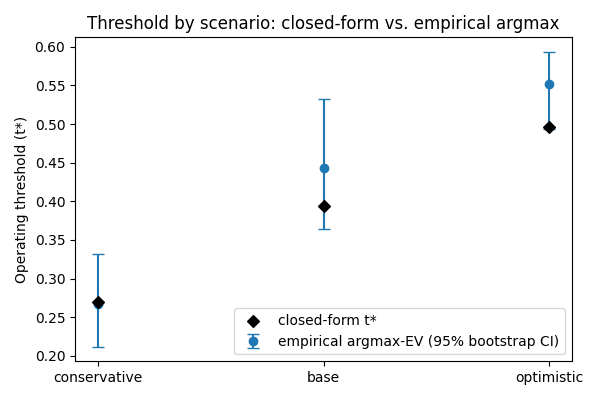


Shipped threshold (base scenario): 0.3941
Calibration method: sigmoid


In [6]:
threshold_rows = []
for name, scenario in threshold_payload["scenarios"].items():
    ci = scenario["argmax_ev_bootstrap_ci"]
    threshold_rows.append(
        {
            "scenario": name,
            "Threshold (formula)": scenario["threshold"],
            "Threshold (empirical)": scenario["argmax_ev_threshold"],
            "95% CI lower": ci[0],
            "95% CI upper": ci[1],
            "Within CI?": "Yes" if scenario["within_ci"] else "No",
            "Contact rate": scenario["implied_contact_rate"],
        }
    )
threshold_df = pd.DataFrame(threshold_rows).set_index("scenario")
display(
    threshold_df.style.format(
        {
            "Threshold (formula)": "{:.4f}",
            "Threshold (empirical)": "{:.4f}",
            "95% CI lower": "{:.4f}",
            "95% CI upper": "{:.4f}",
            "Contact rate": "{:.1%}",
        }
    )
)

scenario_plot_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="figures/threshold_by_scenario.png"
)
display(Image(filename=scenario_plot_path))

assert threshold_payload["scenarios"]["base"]["within_ci"], (
    "The shipped base-scenario threshold no longer agrees with the empirical "
    "argmax-EV diagnostic — this notebook's narrative below assumes agreement "
    "and needs revisiting if this assertion ever fails."
)
print(f"\nShipped threshold (base scenario): {threshold_payload['threshold']:.4f}")
print(f"Calibration method: {threshold_payload['calibration_method']}")

Across all three scenarios, the formula and the empirical check land within about 0.05 of each other, and the formula always falls inside the empirical check's uncertainty range (the vertical bars) — the small gap is just noise from estimating an optimum on limited data, not a sign the formula is wrong. Raising the assumed retention rate (conservative → optimistic) also raises the threshold, which shrinks the **contact rate** — the share of customers who would actually be flagged for outreach — from about 40% down to about 25%.

### Expected-value curves, by scenario

Expected value follows the same cost logic as the threshold itself, made concrete as a formula:

**expected value(t) = [ caught churners × (retention value − cost) − wasted contacts × cost ] ÷ total customers**

Every churner the rule "contact if `q ≥ t`" catches in time pays back the retention value minus the cost of the call; every contact wasted on someone who wasn't going to churn is a pure loss of that cost. Averaging across the whole customer base gives one dollar figure per cutoff `t` — the number this section plots.

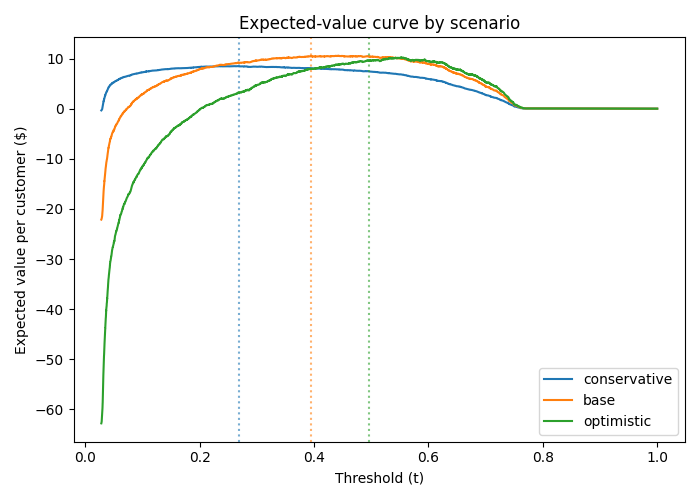

In [7]:
ev_curve_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="figures/expected_value_by_scenario.png"
)
display(Image(filename=ev_curve_path))

The chart above traces that dollar value across every possible cutoff, for all three scenarios. Contacting almost everyone (`t` near 0) costs money outright — sharply so for base and optimistic, whose higher cost per contact makes over-contacting expensive; conservative's much cheaper cost per contact keeps it closer to break-even. All three climb to a broad plateau of near-best cutoffs before falling back to exactly $0 as the threshold approaches 1 (contacting no one).

For a business stakeholder, the takeaway is that neither extreme pays — contacting everyone wastes money on people who were never at risk, and contacting no one means giving up on every customer who could have been talked into staying — and that same middle-ground logic is why **base**, not conservative or optimistic, ships: it uses the typical, median cost and retention-rate assumptions, with the other two bracketing the uncertainty. The broad plateau is reassuring too: nearby cutoffs perform almost as well, so a slightly-off threshold costs little, which is also why each `t*` (dotted line) sits somewhere on that plateau rather than exactly at the peak.

### Retention-rate sensitivity

The retention rate `r` is the fraction of contacted churners the offer actually saves — the one parameter this dataset cannot supply on its own, taken instead from an industry-benchmark range rather than fit. The sweep below holds the base scenario's cost and LTV fixed and varies only `r`, showing how much the shipped threshold would move under a different assumption.

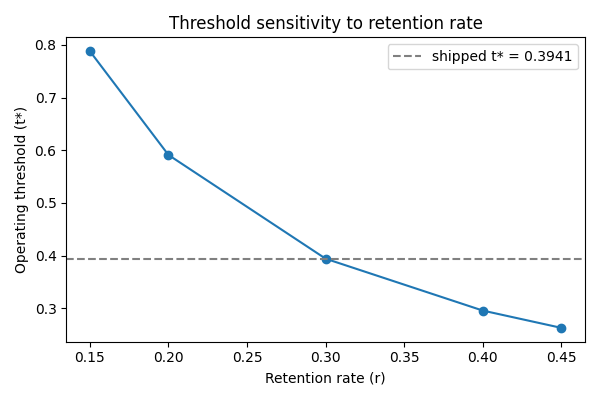

In [8]:
sensitivity_path = mlflow.artifacts.download_artifacts(
    run_id=run_id, artifact_path="figures/threshold_sensitivity.png"
)
display(Image(filename=sensitivity_path))

The operational threshold `t*` is inversely proportional to the retention rate `r` — halving the assumed retention rate exactly doubles the threshold, since `t*` and `r` are related by pure inverse proportionality once cost and lifetime value are fixed. Across the range tested here, the shipped threshold of 0.39 would need to rise to about 0.79 if the offer only saves half as many customers as assumed (`r = 0.15`), or could fall to about 0.26 if it saves nearly half again as many (`r = 0.45`).

For a business stakeholder, this means the offer's real-world effectiveness has direct financial consequences: if `r` turns out lower than assumed, the shipped threshold is too low and the team ends up contacting more customers than the offer's actual success rate justifies; if `r` is higher, it's too conservative and leaves customers uncontacted who could have been saved.

## Summary

This notebook loads the sigmoid-vs-isotonic calibration method selection and the closed-form cost-sensitive threshold derivation — both already computed by `calibrate.py` and `threshold.py` — and renders their reliability diagram, cost breakdown, agreement diagnostics, EV curves, and retention-rate sensitivity. Logic lives in those two modules; this notebook only loads and renders.

Sigmoid was selected over isotonic — better ranking, despite isotonic's edge on Brier and ECE — recovering a Brier Skill Score of 0.31. The shipped threshold (`t* = 0.3941`, 30.8% contact rate) agrees with its empirical check, but is conditional on the assumed retention rate: the sensitivity sweep shows it ranging from 0.26 to 0.79 across plausible values of `r`. Full narrative: **[§5 Probability Calibration](../ANALYSIS.md#5-probability-calibration)** and **[§6 Business Impact & Threshold Selection](../ANALYSIS.md#6-business-impact--threshold-selection)** in `ANALYSIS.md`.